In [34]:
import numpy as np
import time
import matplotlib.pyplot as plt

N=500
x = np.linspace(-1, 1, N)
# np.random.seed(0)
# x = np.sort(np.random.uniform(-1, 1, N))

Construct the matrix

In [35]:
A = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        if i == j:
            A[i,j] = 100
        else:
            A[i,j] = 1/abs(x[i]-x[j])

In [36]:
A

array([[100.        , 249.5       , 124.75      , ...,   0.50201207,
          0.50100402,   0.5       ],
       [249.5       , 100.        , 249.5       , ...,   0.50302419,
          0.50201207,   0.50100402],
       [124.75      , 249.5       , 100.        , ...,   0.5040404 ,
          0.50302419,   0.50201207],
       ...,
       [  0.50201207,   0.50302419,   0.5040404 , ..., 100.        ,
        249.5       , 124.75      ],
       [  0.50100402,   0.50201207,   0.50302419, ..., 249.5       ,
        100.        , 249.5       ],
       [  0.5       ,   0.50100402,   0.50201207, ..., 124.75      ,
        249.5       , 100.        ]])

# H Matrices Utils

In [37]:
def split_indices(start, end):
    mid = (start + end)//2
    return (start, mid), (mid, end)

In [38]:
def numerical_rank(block, eps=1e-6):
    U, S, Vt = np.linalg.svd(block)
    S_norm = S / S[0] #normalising
    rank = np.sum(S_norm > eps)
    return rank, S_norm

In [39]:
def isLowRankMatrix(row_range, col_range): #checking if matrix is off diagonal (off diagonal => low-rank)
    r0, r1 = row_range
    c0, c1 = col_range

    # overlap check
    isOffDiag = r1 <= c0 or c1 <= r0
    
    return isOffDiag

# Chebyshev Implementation

In [40]:
import numpy as np
from scipy.stats import norm

In [41]:
# def chebyshev_polynomials(x, p):
#     x = np.asarray(x)
#     T = np.zeros((len(x), p))

#     T[:, 0] = 1.0
#     if p > 1:
#         T[:, 1] = x

#     for n in range(2, p):
#         T[:, n] = 2 * x * T[:, n-1] - T[:, n-2]

#     return T


# def chebyshev_points(p):
#     k = np.arange(p)
#     return np.cos((2 * k + 1) * np.pi / (2 * p))


# def scale_to_minus1_1(x, a, b):
#     return (2 * x - (a + b)) / (b - a)


In [42]:
# def kernel_entry(z_i, x_j, h):
#     """
#     Returns single kernel matrix entry.
#     K_ij = Phi((z_i - x_j)/h)
#     """
#     return norm.cdf((z_i - x_j) / h)


# def kernel_matrix(z_block, x_block, h):
#     """
#     Build full kernel matrix using entry definition.
#     (Clear mathematically — not optimized for speed)
#     """
#     Nz = len(z_block)
#     Nx = len(x_block)

#     K = np.zeros((Nz, Nx))

#     for i in range(Nz):
#         for j in range(Nx):
#             K[i, j] = kernel_entry(z_block[i], x_block[j], h)

#     return K


In [43]:
def kernel_entry(x_i, x_j):
    if x_i == x_j:
        return 100.0
    else:
        return 1.0 / abs(x_i - x_j)

def kernel_matrix(x_block, y_block):
    Nx = len(x_block)
    Ny = len(y_block)

    K = np.zeros((Nx, Ny))

    for i in range(Nx):
        for j in range(Ny):
            K[i,j] = kernel_entry(x_block[i], y_block[j])

    return K


def chebyshev_points(p):
    k = np.arange(p)
    return np.cos((2*k+1)*np.pi/(2*p))

def chebyshev_polynomials(x, p):
    x = np.asarray(x)
    T = np.zeros((len(x), p))

    T[:,0] = 1.0
    if p > 1:
        T[:,1] = x

    for n in range(2,p):
        T[:,n] = 2*x*T[:,n-1] - T[:,n-2]

    return T

def scale_to_minus1_1(x,a,b):
    return (2*x - (a+b)) / (b-a)


def build_interpolation_matrix(x_block, p):

    a,b = x_block.min(), x_block.max()

    x_scaled = scale_to_minus1_1(x_block, a, b)

    T = chebyshev_polynomials(x_scaled, p)

    t = chebyshev_points(p)
    Tt = chebyshev_polynomials(t, p)

    gamma = np.ones(p)
    gamma[0] = 0.5
    W = (2/p)*gamma

    return T @ (W[:,None]*Tt.T)


def compute_S_block(x_row, x_col, p):

    t = chebyshev_points(p)

    ar, br = x_row.min(), x_row.max()
    ac, bc = x_col.min(), x_col.max()

    xr = 0.5*(br-ar)*t + 0.5*(br+ar)
    xc = 0.5*(bc-ac)*t + 0.5*(bc+ac)

    return kernel_matrix(xr, xc)

In [44]:
class HMatrixCheb:

    def __init__(self, x, p=8, max_level=4):

        self.x = x
        self.N = len(x)
        self.p = p
        self.max_level = max_level

        self.blocks = {}
        self.row_clusters = {}
        self.col_clusters = {}

        self.build((0,self.N),(0,self.N), level=0)


    def build_row_cluster(self, row_range):

        if row_range in self.row_clusters:
            return

        r0,r1 = row_range
        x_row = self.x[r0:r1]

        U = build_interpolation_matrix(x_row, self.p)

        self.row_clusters[row_range] = U


    def build_col_cluster(self, col_range):

        if col_range in self.col_clusters:
            return

        c0,c1 = col_range
        x_col = self.x[c0:c1]

        V = build_interpolation_matrix(x_col, self.p)

        self.col_clusters[col_range] = V


    def build(self, row_range, col_range, level):

        r0,r1 = row_range
        c0,c1 = col_range

        # LOW RANK BLOCK
        if isLowRankMatrix(row_range, col_range):

            self.build_row_cluster(row_range)
            self.build_col_cluster(col_range)

            x_row = self.x[r0:r1]
            x_col = self.x[c0:c1]

            S = compute_S_block(x_row, x_col, self.p)

            self.blocks[(row_range,col_range)] = (
                "lowrank", row_range, col_range, S
            )
            return


        # DENSE LEAF
        if level == self.max_level:

            x_row = self.x[r0:r1]
            x_col = self.x[c0:c1]

            block = kernel_matrix(x_row, x_col)

            self.blocks[(row_range,col_range)] = (
                "dense", block
            )
            return


        # RECURSION
        rL,rR = split_indices(r0,r1)
        cL,cR = split_indices(c0,c1)

        self.build(rL,cL,level+1)
        self.build(rL,cR,level+1)
        self.build(rR,cL,level+1)
        self.build(rR,cR,level+1)


    def mult(self, v):

        y = np.zeros_like(v)

        for key, block in self.blocks.items():

            row_range, col_range = key
            r0,r1 = row_range
            c0,c1 = col_range

            if block[0] == "dense":

                y[r0:r1] += block[1] @ v[c0:c1]

            else:

                _, row_id, col_id, S = block

                U = self.row_clusters[row_id]
                V = self.col_clusters[col_id]

                y[r0:r1] += U @ (S @ (V.T @ v[c0:c1]))

        return y

# Comparisions

In [46]:
def hmatrix_cheb_memory(H):

    total = 0

    for U in H.row_clusters.values():
        total += U.size

    for V in H.col_clusters.values():
        total += V.size

    for block in H.blocks.values():
        if block[0] == "dense":
            total += block[1].size
        else:
            S = block[3]
            total += S.size

    return total


In [47]:
N = 600
x = np.linspace(0,1,N)
X = np.ones(N)

A = kernel_matrix(x,x)
y_exact = A @ X

ps = [4, 6, 8, 10, 12, 16]

errors = []
mems = []


for p in ps:
    H = HMatrixCheb(x, p=p, max_level=4)

    # memory
    mems.append(hmatrix_cheb_memory(H))

    t0 = time.perf_counter()
    y = H.mult(X)

    # error
    err = np.linalg.norm(y_exact-y)/np.linalg.norm(y_exact)
    errors.append(err)


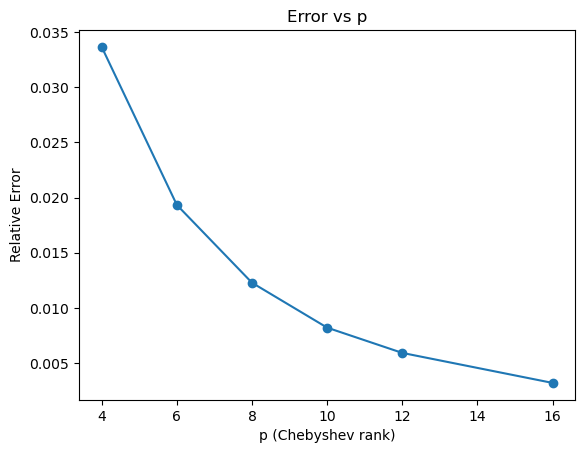

In [48]:
plt.figure()
plt.plot(ps, errors, 'o-')
plt.xlabel("p (Chebyshev rank)")
plt.ylabel("Relative Error")
plt.title("Error vs p")
plt.show()


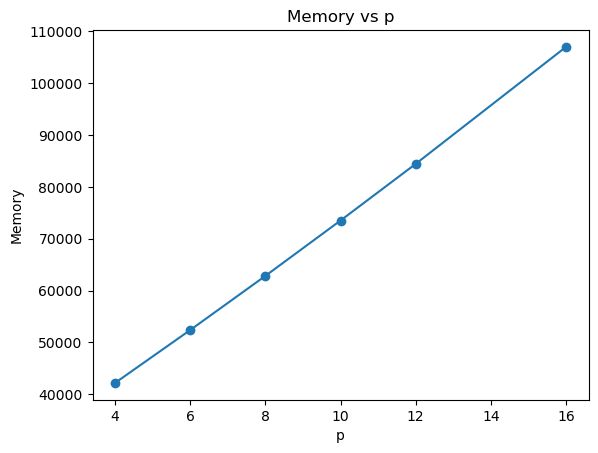

In [49]:
plt.figure()
plt.plot(ps, mems, 'o-')
plt.xlabel("p")
plt.ylabel("Memory")
plt.title("Memory vs p")
plt.show()
